In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
conn = sqlite3.connect("../bluestock_mf.db")

In [3]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance


In [4]:
funds = pd.read_sql("SELECT * FROM dim_fund", conn)

funds.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
print(funds.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [6]:
nav = pd.read_sql("SELECT * FROM fact_nav", conn)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [8]:
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [9]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [10]:
performance = pd.read_sql("SELECT * FROM fact_performance", conn)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [11]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [12]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [13]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [14]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [15]:
risk_metrics = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # Skip funds with too little data
    if len(returns) < 30:
        continue

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Conditional VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

In [16]:
risk_df = risk_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [17]:
risk_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [18]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [19]:
rolling_list = []

for fund, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    returns = group["daily_return"]

    group["rolling_sharpe"] = (
        returns.rolling(window=90).mean()
        / returns.rolling(window=90).std()
    ) * np.sqrt(252)

    rolling_list.append(group)

rolling_df = pd.concat(rolling_list, ignore_index=True)

In [20]:
rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [21]:
rolling_df = rolling_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [22]:
top5 = rolling_df["amfi_code"].drop_duplicates().head(5)

In [23]:
rolling_df[
    rolling_df["amfi_code"].isin(top5)
][["amfi_code", "scheme_name"]].drop_duplicates()

,amfi_code,scheme_name
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1150,100025,HDFC Short Term Debt Fund - Regular - Growth
2300,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450,101206,ABSL Frontline Equity Fund - Regular - Growth
4600,101207,ABSL Small Cap Fund - Regular - Growth


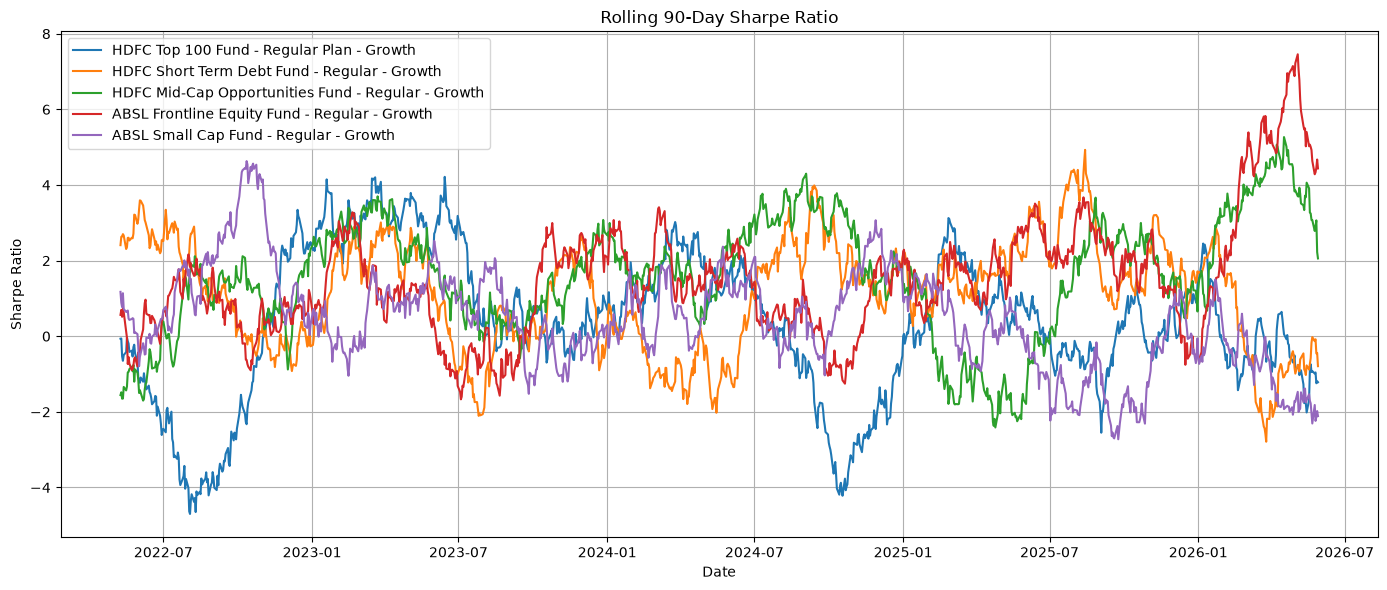

In [24]:
plt.figure(figsize=(14,6))

for fund in top5:

    temp = rolling_df[
        rolling_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [25]:
charts/
    rolling_sharpe_chart.png

SyntaxError: invalid syntax (2036519463.py, line 1)

In [26]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [27]:
cohort = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

cohort.columns = [
    "investor_id",
    "cohort_year"
]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [28]:
transactions = transactions.merge(
    cohort,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING,2024


In [29]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

In [30]:
avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [31]:
total_investment = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_investment

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [32]:
top_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

In [33]:
top_fund = top_fund.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund.head()

,cohort_year,amfi_code,count,scheme_name
0,2024,100016,830,HDFC Top 100 Fund - Regular Plan - Growth
1,2024,100025,791,HDFC Short Term Debt Fund - Regular - Growth
2,2024,100033,781,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,2024,101206,803,ABSL Frontline Equity Fund - Regular - Growth
4,2024,101207,844,ABSL Small Cap Fund - Regular - Growth


In [34]:
cohort_summary = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(
        top_fund[["cohort_year", "scheme_name"]],
        on="cohort_year"
    )
)

cohort_summary.rename(
    columns={
        "scheme_name": "top_fund_preference"
    },
    inplace=True
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,3491125187,HDFC Top 100 Fund - Regular Plan - Growth
1,2024,10996.885825,3491125187,HDFC Short Term Debt Fund - Regular - Growth
2,2024,10996.885825,3491125187,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,2024,10996.885825,3491125187,ABSL Frontline Equity Fund - Regular - Growth
4,2024,10996.885825,3491125187,ABSL Small Cap Fund - Regular - Growth
...,...,...,...,...
75,2025,13505.209581,30455243,Mirae Asset Emerging Bluechip Fund - Regular -...
76,2025,13505.209581,30455243,Mirae Asset Tax Saver Fund - Regular - Growth
77,2025,13505.209581,30455243,DSP Top 100 Equity Fund - Regular - Growth
78,2025,13505.209581,30455243,DSP Midcap Fund - Regular - Growth


In [35]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [36]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [37]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [38]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [39]:
sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,VERIFIED,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,PENDING,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,VERIFIED,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,VERIFIED,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,VERIFIED,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,VERIFIED,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,VERIFIED,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,VERIFIED,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,VERIFIED,2024,28.0


In [40]:
sip_summary = (
    sip.groupby("investor_id")
       .agg(
           sip_transactions=("transaction_date", "count"),
           avg_gap_days=("gap_days", "mean")
       )
       .reset_index()
)

In [41]:
sip_summary = sip_summary[
    sip_summary["sip_transactions"] >= 6
]

In [42]:
sip_summary["status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

In [43]:
sip_summary.head()

,investor_id,sip_transactions,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [44]:
sip_summary["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [45]:
continuity_rate = (
    (sip_summary["status"] == "Healthy").mean() * 100
)

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 2.20%


In [46]:
sip_summary.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [47]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [48]:
performance.to_csv("../reports/recommendation_data.csv", index=False)

In [49]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [50]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [51]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [52]:
holdings["weight_decimal"] = holdings["weight_pct"] / 100

In [53]:
hhi = (
    holdings.groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [54]:
hhi = hhi.merge(
    funds[
        ["amfi_code", "scheme_name", "category", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category,fund_house
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity,HDFC Mutual Fund
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,HDFC Mutual Fund
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,UTI Mutual Fund


In [55]:
equity_hhi = hhi[
    hhi["category"].str.contains("Equity", case=False, na=False)
]

equity_hhi.head()

,amfi_code,HHI,scheme_name,category,fund_house
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity,HDFC Mutual Fund
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,HDFC Mutual Fund
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,UTI Mutual Fund


In [56]:
equity_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category,fund_house
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity,Axis Mutual Fund
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity,Aditya Birla Sun Life MF
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity,SBI Mutual Fund
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity,UTI Mutual Fund
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity,Nippon India MF
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity,Mirae Asset MF
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity,ICICI Prudential MF
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,ICICI Prudential MF
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,HDFC Mutual Fund
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity,Kotak Mahindra MF


In [57]:
equity_hhi.sort_values(
    "HHI"
).head(10)

,amfi_code,HHI,scheme_name,category,fund_house
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth,Equity,SBI Mutual Fund
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth,Equity,SBI Mutual Fund
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity,Nippon India MF
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth,Equity,ICICI Prudential MF
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth,Equity,Axis Mutual Fund
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity,UTI Mutual Fund
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth,Equity,DSP Mutual Fund
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth,Equity,SBI Mutual Fund
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity,Nippon India MF
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth,Equity,Kotak Mahindra MF


In [58]:
equity_hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

## Insight 1: Downside Risk (VaR & CVaR)

Historical VaR and CVaR analysis shows that some schemes have significantly higher downside risk than others. Funds with larger negative VaR and CVaR values are more vulnerable to extreme market movements.

## Insight 2: Rolling Sharpe Ratio

The rolling 90-day Sharpe Ratio demonstrates how risk-adjusted performance changes over time. Funds with consistently higher Sharpe Ratios provide better returns relative to the level of risk taken.

## Insight 3: Investor Cohort Analysis

Investor cohorts based on their first transaction year reveal differences in investment behaviour. Comparing average SIP amounts and total invested helps identify which cohorts contribute the most capital to mutual funds.

## Insight 4: SIP Continuity

The SIP continuity analysis identifies investors who may discontinue their investments. Investors with an average SIP gap greater than 35 days are classified as "At-Risk", while the remaining investors demonstrate consistent investment discipline.

## Insight 5: Portfolio Concentration (HHI)

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration. Equity funds with higher HHI values have concentrated holdings in fewer sectors, whereas lower HHI values indicate better diversification across sectors.